In [1]:
import ee
# from rich.jupyter import display
# from sympy.stats.sampling.sample_numpy import numpy

ee.Authenticate()

True

In [2]:
ee.Initialize(project="climateconsciousimli")  # assumes you've authenticated already

In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
# import torch
import numpy as np

In [4]:
# Define bounding box (lon_min, lat_min, lon_max, lat_max)
lat_min, lat_max = 28.0, 29.39
lat_avg = (lat_max + lat_min) / 2
lon_min, lon_max = 76.3, 79.0
lon_avg = (lon_max + lon_min) / 2

stepp = 0.25


roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
pixel = ee.Geometry.Point([77.0, 29.0])
micropixel = ee.Geometry.Rectangle([lon_avg-stepp, lat_avg-stepp, lon_avg+stepp, lat_avg+stepp])
sampling_scale = 10000
start_date = '2024-02-01'
end_date = '2024-02-11'

- Everything is the same till now.
- `scale` is \~8km.
- `pixel` is one point.
- `roi` is the region.
- `micropixel` is a smaller region to make computation easier
- Now collect the data accordingly :

In [5]:
"""
Can define multiple collections (wind, SO2, NO2). Prepare what we're doing for each. Then feed outputs for all. No merging required as such, except right before training/input into a model.
"""

collection = (
    ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .filterBounds(roi)# REPLACE WITH ROI
    .filterDate(start_date, end_date)
    .select('tropospheric_NO2_column_number_density')
)

- The function `make_coarse` given below is of interest. In words (which I myself don't fully understand yet), it takes in raw data, reduces its resolution by taking a mean (how is that done/executed?). It then "reprojeccts" the data, with some scale in mind, giving us the "coarse" data.
- The raw data has each pixel representing ~7km$^2$. We do not wish to work with this. To "access" the data, we call several functions :
-   `reduceResolution`
-   `reproject` onto the grid.
-   `focal_mean` : treat "Null" by taking a spatial mean.
-   `copyProperties` : preserves `system:time_start`.

In [6]:
def make_coarse(image):
    return (image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            bestEffort=True
        )
        .reproject(
            scale=1100,
            crs='EPSG:4326'
        )#.focal_mean(radius=4, units='pixels')
        .copyProperties(image, ['system:time_start'])
    )

coarse_collection = collection.map(make_coarse) # This (possibly coarse) collection will be henceforth be used.

size_of_coll = coarse_collection.size().getInfo()
print(f"Size of collection is {size_of_coll}. In particular, coarse_collection.getInfo()['features'] has that many items.")
print()
print(f"This means we have ~{size_of_coll} entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have {size_of_coll} measurements for the region, and the region is (say) 11*11 pixels, then we have ~{11*11*size_of_coll} measurements. Many of these may be null!")
# print(coarse_collection.first().getInfo()['properties']['system:time_start']) # need to parse as date-time

Size of collection is 141. In particular, coarse_collection.getInfo()['features'] has that many items.

This means we have ~141 entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have 141 measurements for the region, and the region is (say) 11*11 pixels, then we have ~17061 measurements. Many of these may be null!


In [7]:
def sample_image(image):
    samples = image.sample(
        region=roi,
        scale=sampling_scale,
        geometries=True,
        dropNulls=True
    )
    # return samples.map(lambda f: f.set('system:time_start', f.getInfo()['properties']['system:time_start'])).map(lambda f: f.set(
    #     'date', image.date().format('YYYY-MM-dd')
    # ))
    time_start = image.get('system:time_start')
    return samples.map(lambda f: f.set({
        # 'system:time_start': time_start,
        'date': ee.Date(time_start).format('YYYY-MM-dd'),
        'datetime': ee.Date(time_start).format('YYYY-MM-dd HH:mm:ss')
    }))

fc = coarse_collection.map(sample_image).flatten()
print(f"Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :")

Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :


In [8]:
features = fc.getInfo()['features']
# print(f"Features are : \n\n{features}\n\n")
proppies = features[0]['properties'] # ['tropospheric_NO2_column_number_density'])
print(f"Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : \n\n{proppies}\n\n")
print()
print(f"proppies.get('tropospheric_NO2_column_number_density') gives {proppies.get('tropospheric_NO2_column_number_density')}")
print("This applies for proppies being the first record in the given time range. Now we will try them all out ....\n\n\n")


n_feature_instances = len(features)
print(f"number of 'features' is {n_feature_instances}, as we calculated above.")
print(features[0].get('properties'))
for i in range(n_feature_instances):
    print(features[i]['properties'].get('tropospheric_NO2_column_number_density'), features[i]['properties'].get('datetime'))
# for j in proppies:
#     print(j)
#     print()

Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : 

{'date': '2024-02-01', 'datetime': '2024-02-01 06:45:46', 'tropospheric_NO2_column_number_density': 3.360157710135046e-05}



proppies.get('tropospheric_NO2_column_number_density') gives 3.360157710135046e-05
This applies for proppies being the first record in the given time range. Now we will try them all out ....



number of 'features' is 3192, as we calculated above.
{'date': '2024-02-01', 'datetime': '2024-02-01 06:45:46', 'tropospheric_NO2_column_number_density': 3.360157710135046e-05}
3.360157710135046e-05 2024-02-01 06:45:46
4.5703612526640844e-05 2024-02-02 06:26:49
2.892058006166106e-05 2024-02-02 06:26:49
3.420613575143119e-05 2024-02-02 06:26:49
4.236841050444715e-05 2024-02-02 06:26:49
3.7364901230755276e-05 2024-02-02 06:26:49
2.198983623152081e-05 2024-02-02 06:26:4

In [9]:
features = fc.getInfo()['features']

rows = []
for f in features:
    props = f['properties']
    coords = f['geometry']['coordinates']

    if 'tropospheric_NO2_column_number_density' in props:
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'date': props['date'],
            'datetime': props['datetime'],
            'NO2': props['tropospheric_NO2_column_number_density']
        })

df = pd.DataFrame(rows)
df

,lon,lat,date,datetime,NO2
0,78.827166,29.240162,2024-02-01,2024-02-01 06:45:46,0.000034
1,77.210199,29.329994,2024-02-02,2024-02-02 06:26:49,0.000046
2,77.300030,29.329994,2024-02-02,2024-02-02 06:26:49,0.000029
3,77.389862,29.329994,2024-02-02,2024-02-02 06:26:49,0.000034
4,77.479693,29.329994,2024-02-02,2024-02-02 06:26:49,0.000042
...,...,...,...,...,...
3187,78.557672,28.072353,2024-02-10,2024-02-10 07:18:14,0.000048
3188,78.647503,28.072353,2024-02-10,2024-02-10 07:18:14,0.000050
3189,78.737335,28.072353,2024-02-10,2024-02-10 07:18:14,0.000057
3190,78.827166,28.072353,2024-02-10,2024-02-10 07:18:14,0.000048


In [10]:
unique_dates = sorted(df['date'].unique())
print(len(df['date']))
selected_dates = unique_dates[:]

3192


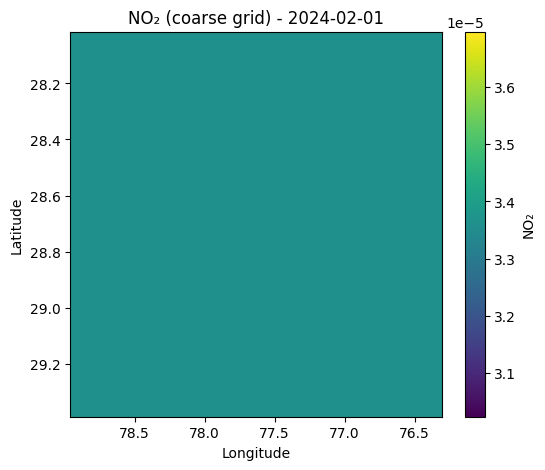

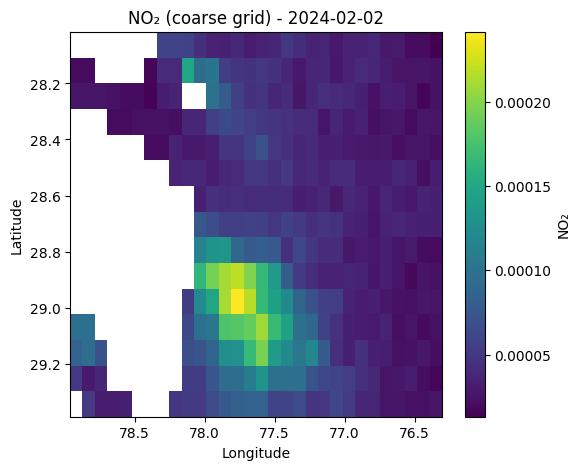

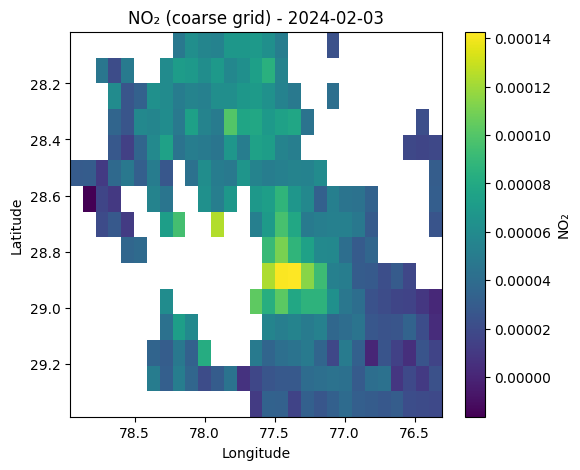

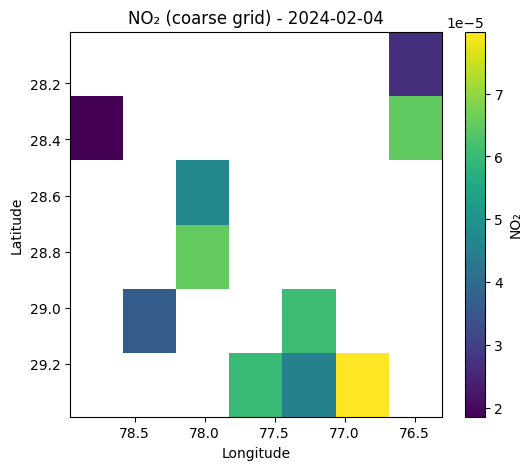

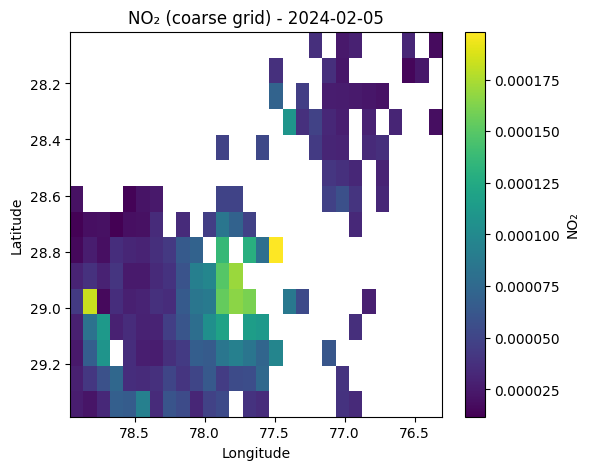

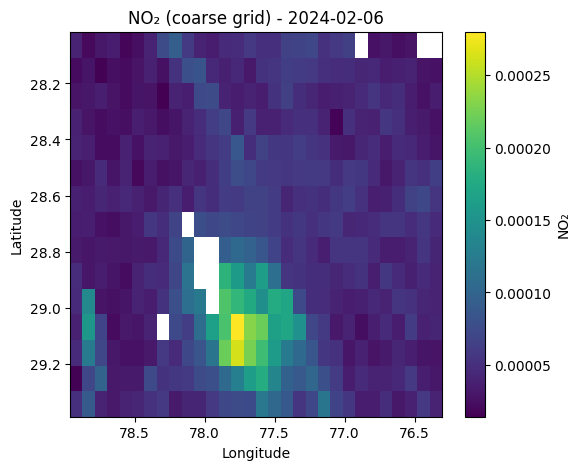

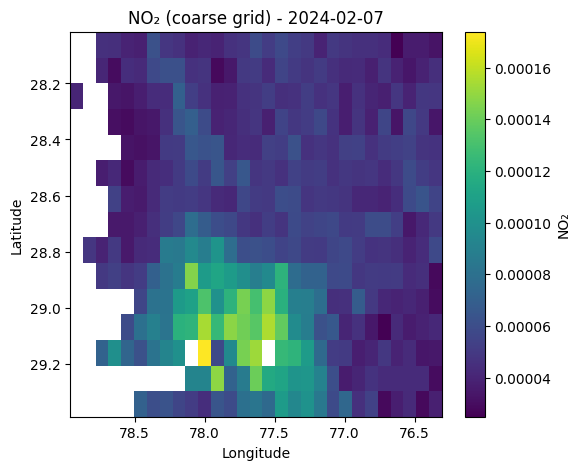

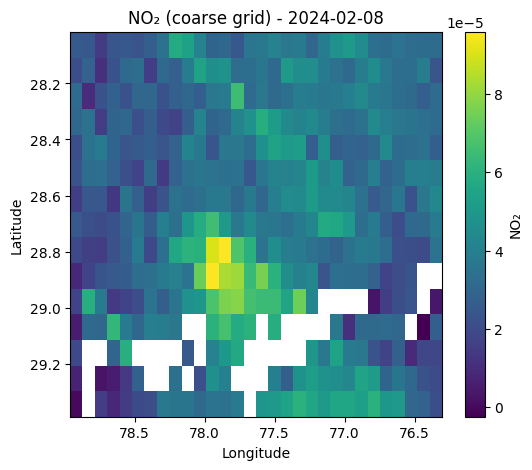

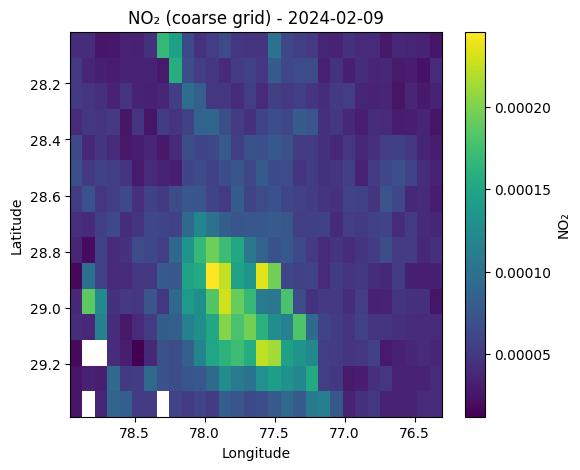

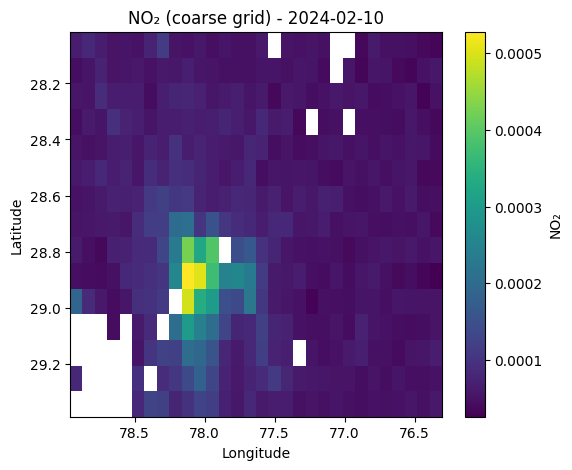

29.32999402650238 28.07235262873505
78.91699770989997 76.31188338595337


In [11]:
latt = []
lonn = []

for d in selected_dates:
    subset = df[df['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            78.96056600117977, 76.30334939075422,
            29.38973199289633, 28.015309608193462
            # pivot.columns.min(), pivot.columns.max(),
            # pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

print(max(latt), min(latt))
print(max(lonn), min(lonn))

In [12]:
# import pandas as pd
# import numpy as np

# 1. Create a copy and ensure datetime types
df_interp = df.copy()
df_interp['date'] = pd.to_datetime(df_interp['date'])

# 2. Create complete grid
all_lats = df_interp['lat'].unique()
all_lons = df_interp['lon'].unique()
all_times = sorted(df_interp['date'].unique())
print("hello")
# print(all_times)
# index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'datetime'])
# full_df = pd.DataFrame(index=index).reset_index()

index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'date'])
full_df = pd.DataFrame(index=index).reset_index()

# Merge original data
df_merged = pd.merge(full_df, df_interp, on=['lat', 'lon', 'date'], how='left')
df_merged = df_merged.sort_values(['lat', 'lon', 'date'])


# df_merged['date'] = (df_merged['date']).dt.date

# 3. Interpolate NO2 values
df_merged['NO2_interpolated'] = df_merged.groupby(['lat', 'lon'])['NO2'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')#.bfill().ffill()
)

print("Original row count:", len(df))
print("Expanded row count:", len(df_merged))
print("Example of filled dates:")
# df_interpolated = df_merged.fillna(0)
print(f"Non-NaN entries of NO2, and of NO2_interpolated are : {df_merged['NO2'].count(), df_merged['NO2_interpolated'].count()}, respectively.")

hello
Original row count: 3192
Expanded row count: 4818
Example of filled dates:
Non-NaN entries of NO2, and of NO2_interpolated are : (np.int64(3192), np.int64(4818)), respectively.


            lat        lon       date             datetime       NO2  \
4747  28.072353  76.311883 2024-02-01                  NaN       NaN   
4748  28.072353  76.311883 2024-02-02                  NaN       NaN   
4749  28.072353  76.311883 2024-02-03                  NaN       NaN   
4750  28.072353  76.311883 2024-02-04                  NaN       NaN   
4751  28.072353  76.311883 2024-02-05  2024-02-05 07:11:28  0.000026   
...         ...        ...        ...                  ...       ...   
541   29.329994  78.916998 2024-02-06                  NaN       NaN   
542   29.329994  78.916998 2024-02-07  2024-02-07 06:33:33  0.000033   
543   29.329994  78.916998 2024-02-08  2024-02-08 07:56:07  0.000033   
544   29.329994  78.916998 2024-02-09  2024-02-09 07:37:10  0.000025   
545   29.329994  78.916998 2024-02-10  2024-02-10 07:18:14  0.000032   

      NO2_interpolated  
4747          0.000026  
4748          0.000026  
4749          0.000026  
4750          0.000026  
4751      

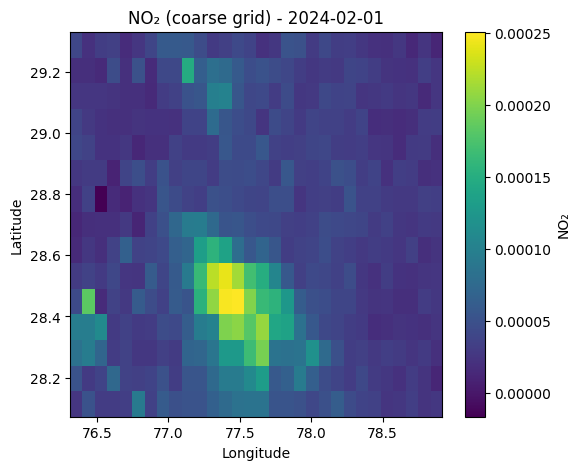

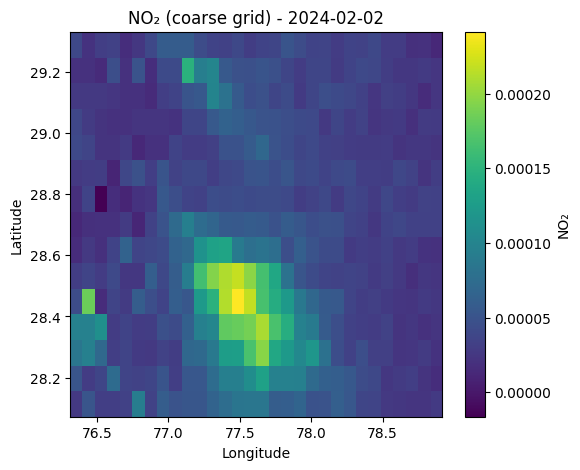

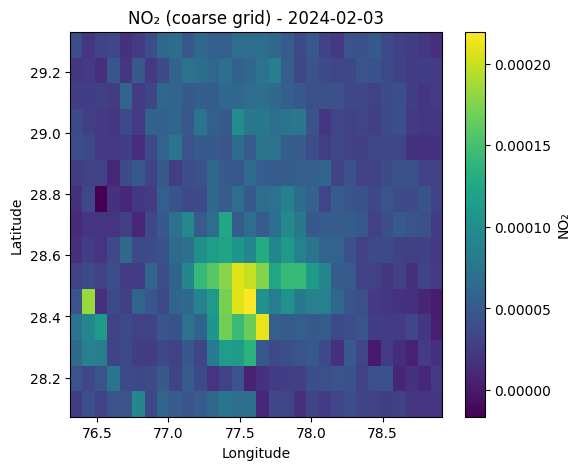

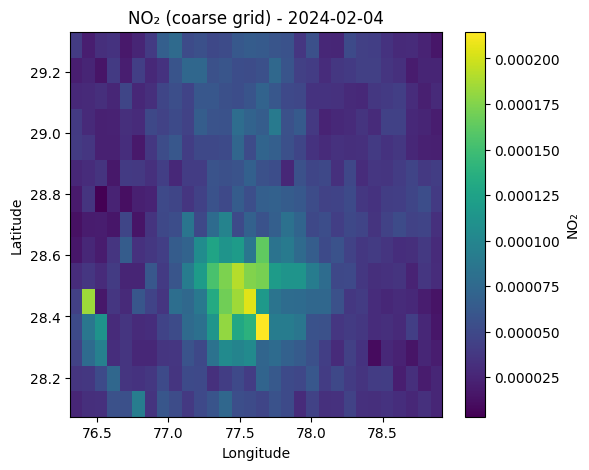

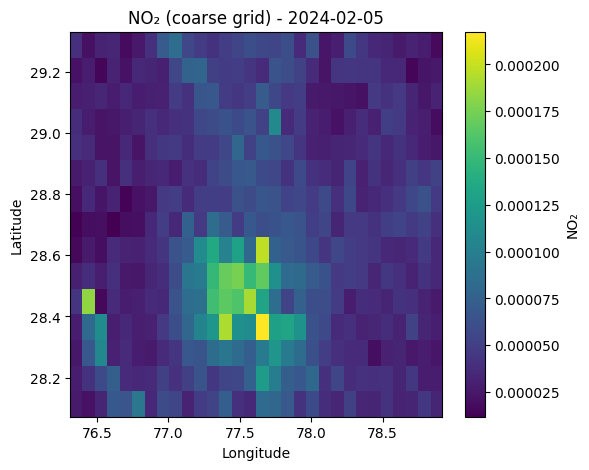

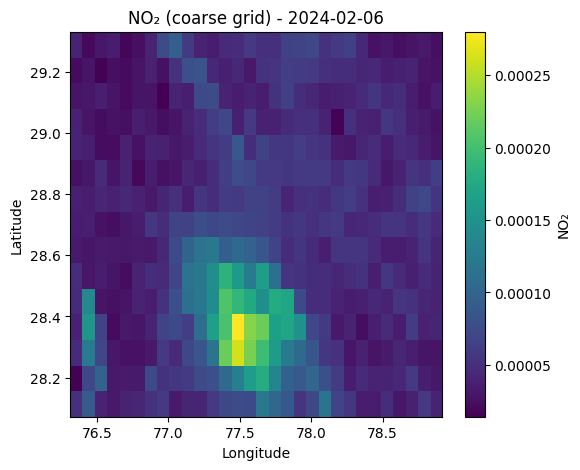

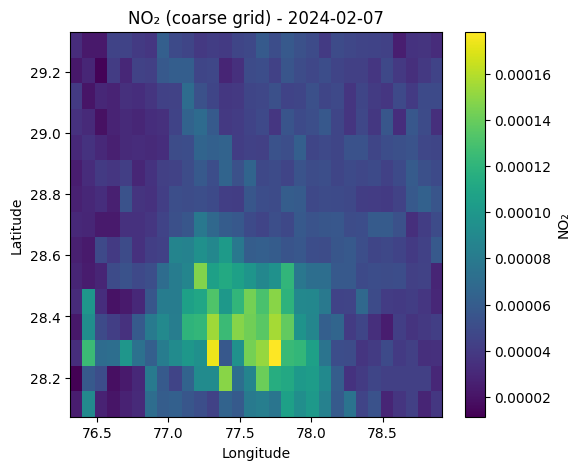

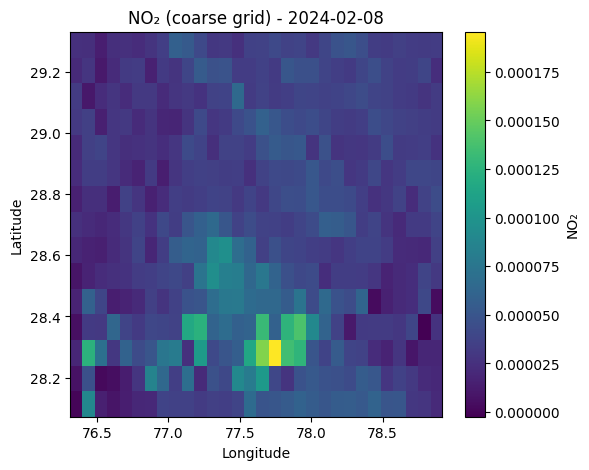

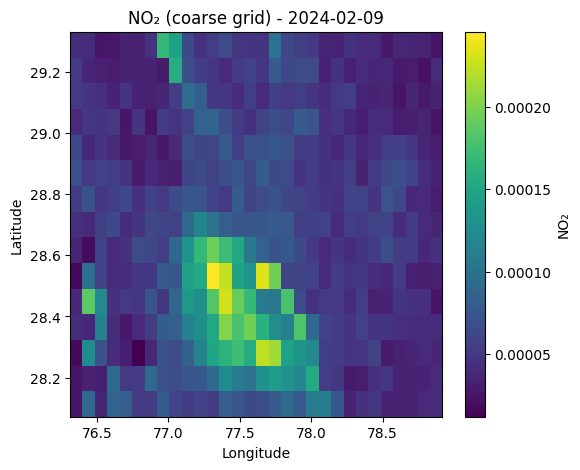

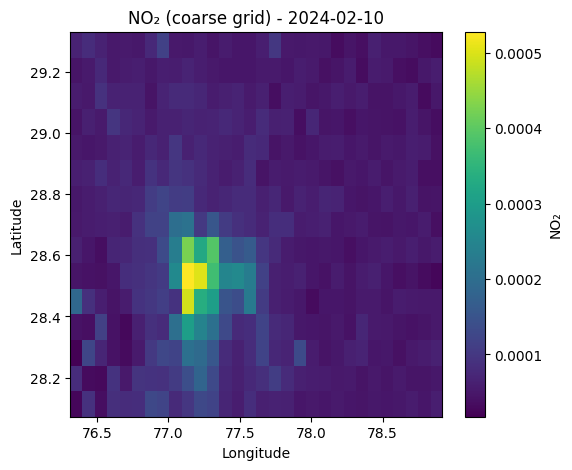

In [14]:
latt = []
lonn = []
print(df_merged)
for d in selected_dates:
    subset = df_merged[df_merged['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2_interpolated'
    )
    pivot.fillna(0.0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            # 78.96056600117977, 76.30334939075422,
            # 29.38973199289633, 28.015309608193462
            pivot.columns.min(), pivot.columns.max(),
            pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# print(max(latt), min(latt))
# print(max(lonn), min(lonn))